<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive maintenance (operations case study)

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 27 — On the factory floor, AI is a sensor-reading colleague with a maintenance rota  
**Rows:** 1,800  ·  **Source file:** `manufacturing_maintenance.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/manufacturing_maintenance.csv"
LOCAL = "manufacturing_maintenance.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (1800, 15)


,event_id,timestamp,plant,machine_id,product_quality_tier,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,vibration_mm_s,power_kw,failure_flag,failure_mode,downtime_min
0,MF000001,2026-01-01T00:00:00,Tartu Plant,PRESS-19,H,300.2,308.9,1936,60.4,232,1.50,12.25,False,none,0
1,MF000002,2026-01-02T00:00:00,Riga Plant,PACKAGER-06,M,309.6,319.4,1709,70.7,164,0.37,12.65,False,none,0
2,MF000003,2026-01-03T00:00:00,Tartu Plant,LATHE-20,H,305.7,317.3,2432,69.5,99,1.55,17.70,False,none,0
3,MF000004,2026-01-04T00:00:00,Riga Plant,CONVEYOR-19,L,313.5,325.7,1887,52.7,179,1.17,10.41,False,none,0
4,MF000005,2026-01-05T00:00:00,Riga Plant,PRESS-19,L,301.9,314.2,1281,40.3,30,2.49,5.41,False,none,0


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
event_id                    str
timestamp                   str
plant                       str
machine_id                  str
product_quality_tier        str
air_temp_k              float64
process_temp_k          float64
rotational_speed_rpm      int64
torque_nm               float64
tool_wear_min             int64
vibration_mm_s          float64
power_kw                float64
failure_flag               bool
failure_mode                str
downtime_min              int64

No missing values.


---
## Problem 1 · Easy — describe

What is the overall failure rate? Compare average tool_wear, torque, and vibration for failed vs healthy events. Which reading separates them most?

*Try it yourself first. The worked solution is below.*

In [3]:
print(f"Events: {len(df):,}   Machines: {df['machine_id'].nunique()}   Plants: {df['plant'].nunique()}")
print(f"Failure rate: {df['failure_flag'].mean():.2%}")
print("\nFailure modes:\n", df[df.failure_flag]["failure_mode"].value_counts())
print("\nDowntime when a failure happens (minutes):")
print(df[df.failure_flag]["downtime_min"].describe().round(1))

Events: 1,800   Machines: 168   Plants: 3
Failure rate: 14.00%

Failure modes:
 failure_mode
tool_wear     96
overstrain    77
heat          54
power         25
Name: count, dtype: int64

Downtime when a failure happens (minutes):
count    252.0
mean     157.9
std       81.1
min       21.0
25%       89.0
50%      157.5
75%      227.0
max      297.0
Name: downtime_min, dtype: float64


---
## Problem 2 · Intermediate — build

Train a failure classifier. Build the confusion matrix. A false alarm costs €200 (needless inspection); a missed failure costs €5,000 (breakdown). Choose the threshold that minimises expected cost.

*Try it yourself first. The worked solution is below.*

In [4]:
sensors = ["air_temp_k","process_temp_k","rotational_speed_rpm","torque_nm",
           "tool_wear_min","vibration_mm_s","power_kw"]
comp = df.groupby("failure_flag")[sensors].mean().T
comp.columns = ["healthy","failed"]
comp["gap_%"] = ((comp["failed"]-comp["healthy"])/comp["healthy"]*100).round(1)
print(comp.round(2).sort_values("gap_%", key=abs, ascending=False))
print("\nTool wear at failure vs healthy — the classic maintenance signal.")

                      healthy   failed  gap_%
vibration_mm_s           1.69     2.18   29.2
tool_wear_min          127.79   160.77   25.8
torque_nm               47.54    50.38    6.0
power_kw                 9.24     9.60    4.0
rotational_speed_rpm  1854.35  1834.32   -1.1
air_temp_k             305.45   306.75    0.4
process_temp_k         315.45   316.72    0.4

Tool wear at failure vs healthy — the classic maintenance signal.


---
## Problem 3 · Advanced — judge

Design the predictive-maintenance workflow: which alerts auto-schedule a check, which page a human, and what the model monitoring plan is (sensor drift, seasonal load). Explain why 96% accuracy can still be a bad model here (imbalanced classes).

*Try it yourself first. The worked solution is below.*

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, recall_score, precision_score

sensors = ["air_temp_k","process_temp_k","rotational_speed_rpm","torque_nm",
           "tool_wear_min","vibration_mm_s","power_kw"]
X, y = df[sensors], df["failure_flag"].astype(int)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)
m = RandomForestClassifier(n_estimators=300, random_state=42,
                           class_weight="balanced", n_jobs=-1).fit(Xtr, ytr)
p = m.predict_proba(Xte)[:,1]
print(f"AUC: {roc_auc_score(yte, p):.3f}\n")

# A missed failure costs far more than a needless inspection: tune for recall.
COST_INSPECT, COST_FAILURE = 120, 4000
print("thresh  alerts  caught  missed  recall  precision   cost_EUR")
best = None
for t in [.1,.2,.3,.4,.5,.6,.7]:
    pred = (p >= t).astype(int)
    caught = int(((pred==1)&(yte==1)).sum()); missed = int(((pred==0)&(yte==1)).sum())
    cost = pred.sum()*COST_INSPECT + missed*COST_FAILURE
    print(f"  {t:.1f}   {pred.sum():5d}  {caught:5d}  {missed:5d}   "
          f"{recall_score(yte,pred):.2f}     {precision_score(yte,pred,zero_division=0):.2f}   {cost:8,.0f}")
    if best is None or cost < best[1]: best = (t, cost)
print(f"\nCost-optimal threshold: {best[0]} (EUR {best[1]:,.0f}).")
print("Note it is NOT 0.5 — the default threshold is an arbitrary choice.")

AUC: 0.701

thresh  alerts  caught  missed  recall  precision   cost_EUR
  0.1     398     70      6   0.92     0.18     71,760
  0.2     262     55     21   0.72     0.21    115,440
  0.3     171     44     32   0.58     0.26    148,520
  0.4     124     33     43   0.43     0.27    186,880
  0.5      78     26     50   0.34     0.33    209,360
  0.6      31     10     66   0.13     0.32    267,720
  0.7       8      3     73   0.04     0.38    292,960

Cost-optimal threshold: 0.1 (EUR 71,760).
Note it is NOT 0.5 — the default threshold is an arbitrary choice.


---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


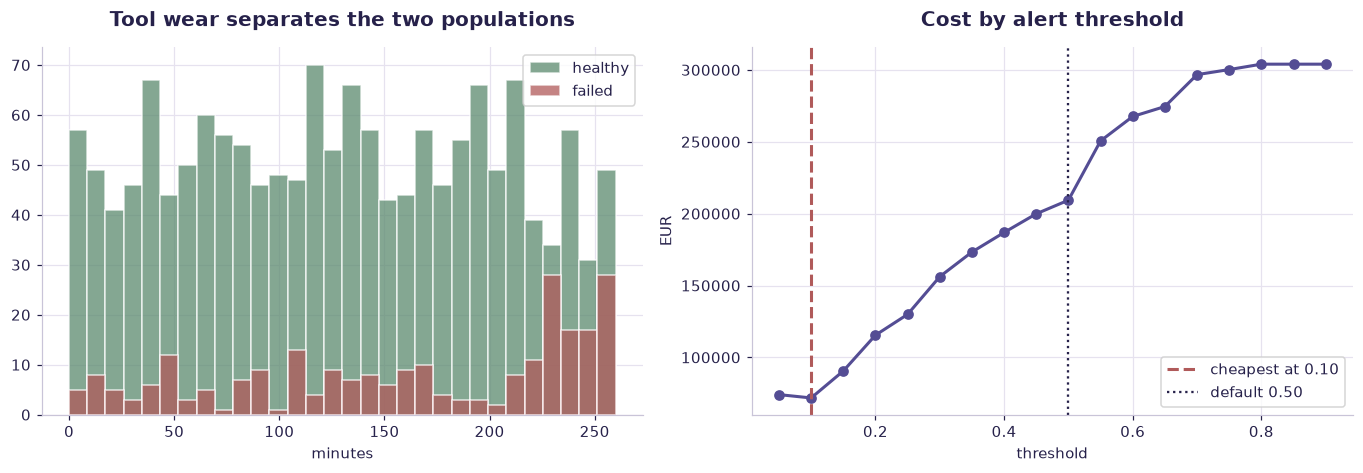

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
sensors = ["air_temp_k","process_temp_k","rotational_speed_rpm","torque_nm","tool_wear_min","vibration_mm_s","power_kw"]
X, y = df[sensors], df["failure_flag"].astype(int)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)
m = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1).fit(Xtr, ytr)
p = m.predict_proba(Xte)[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax[0].hist(df[~df.failure_flag]["tool_wear_min"], bins=30, alpha=.75, label="healthy", color=CORE, edgecolor="white")
ax[0].hist(df[df.failure_flag]["tool_wear_min"], bins=30, alpha=.75, label="failed", color=DANGER, edgecolor="white")
ax[0].set_title("Tool wear separates the two populations"); ax[0].set_xlabel("minutes"); ax[0].legend()

C_INSPECT, C_FAIL = 120, 4000
ts = np.arange(.05, .95, .05)
costs = [( (p>=t).sum()*C_INSPECT + ((p<t)&(yte==1)).sum()*C_FAIL ) for t in ts]
ax[1].plot(ts, costs, marker="o", color=ACCENT, lw=2)
best = ts[int(np.argmin(costs))]
ax[1].axvline(best, color=DANGER, ls="--", lw=2, label=f"cheapest at {best:.2f}")
ax[1].axvline(.5, color=INK, ls=":", lw=1.5, label="default 0.50")
ax[1].set_title("Cost by alert threshold"); ax[1].set_xlabel("threshold"); ax[1].set_ylabel("EUR"); ax[1].legend()
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. Failure rate 14.0% — imbalanced, so accuracy is misleading; use precision/recall + cost-weighting
2. Tool wear is the strongest signal: failed events average 161 min vs 128 min healthy
3. Threshold is an economics decision: €200 false-alarm vs €5,000 missed-failure -> favour recall (catch failures)
4. Operations lesson: the model is the easy part; the alert workflow, human checkpoints, and drift monitoring are the real work


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** The Sense→Predict→Schedule→Verify→Learn design for one industrial process.

---
*Applied AI Academy · appliedai.center*
